# MOP 3231 · Week 2 Lab / Task 1 — Data Preprocessing & Cleaning

**Student:** Imamsidikov
**Dataset:** `data/almaty_apartments_raw.csv` (synthetic Almaty apartment listings, generated for the course — not market data)

The notebook is organised in 8 steps:

| # | Step |
|---|------|
| 1 | Project setup & versions |
| 2 | Load and inspect |
| 3 | Clean and transform (duplicates/reposts, districts, text → numbers) |
| 4 | Sentinels, impossible values, outliers → `data/almaty_apartments_clean.csv` |
| 5 | Missing data (split first, diagnose, masking experiment, fill) |
| 6 | Scaling and encoding (+ sanity-check model) |
| 7 | EDA and cleaning log |
| 8 | Summary and git history |

## Step 1 · Project setup

Isolated venv `.Imamsidikov_ML_task1` (Python 3.12), pinned `requirements.txt`, git repository.
Jupyter is only a tool and is not listed in `requirements.txt`.

In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("Python      ", sys.version.split()[0])
print("NumPy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)

Python       3.12.5
NumPy        2.0.2
pandas       2.3.3
scikit-learn 1.6.1
matplotlib   3.9.4


In [2]:
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

# the cleaning log: one entry per operation (step, operation, rows before, rows after, cells changed)
LOG = []

def log(step, operation, before, after, cells=0):
    LOG.append({"Step": step, "Operation": operation, "Rows before": before,
                "Rows after": after, "Cells changed": int(cells)})
    print(f"[{step}] {operation}: {before} -> {after} rows, {int(cells)} cells changed")

## Step 2 · Load and inspect

**YOUR_ID = 1234** — ⚠️ placeholder: replace with the last four digits of my student ID, used as `random_state` for the 90 % sample and for the train/test split.

In [3]:
YOUR_ID = 1234

raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=YOUR_ID)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("raw file:", raw.shape, "-> my sample:", df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df.describe(include="all").T)

raw file: (1284, 11) -> my sample: (1153, 11)
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           53
building_type         0
ceiling_height_m    130
price_kzt             0
dtype: int64
                   count unique         top freq         mean         std  min     25%     50%     75%     max
listing_id          1153   1080   ALM-10932    3          NaN         NaN  NaN     NaN     NaN     NaN     NaN
listed_date         1153    246  2026-04-18   11          NaN         NaN  NaN     NaN     NaN     NaN     NaN
district            11

### Q1 · Types — raw values of the object columns

In [4]:
for col in ["rooms", "area_m2", "price_kzt", "listed_date"]:
    print(col, df[col].sample(10, random_state=YOUR_ID).tolist())

def non_numeric(s):
    s = s.astype(str)
    return s[~s.str.fullmatch(r"-?\d+(\.\d+)?")]

for col in ["rooms", "area_m2", "price_kzt"]:
    bad = non_numeric(df[col])
    print(f"\n{col}: {len(bad)} non-numeric values, e.g.", bad.drop_duplicates().head(6).tolist())

rooms ['1', '2', '2', '1', '3', 'studio', '3', '2', '4', '3']
area_m2 ['39.5', '56.4', '60.2', '34.3', '94.4', '32.4', '72.4', '544.0', '103.2', '77.0']
price_kzt ['43250000', '26490000', '67870000', '20080000', '68640000', '23030000', '50990000', '25030000', '46030000', '94,030,000']
listed_date ['2026-06-29', '2026-03-29', '2026-05-11', '2026-03-20', '2026-08-08', '2026-07-11', '2026-02-05', '2026-08-24', '2026-02-01', '2026-01-14']

rooms: 30 non-numeric values, e.g. ['studio']

area_m2: 95 non-numeric values, e.g. ['59,4', '54.6 m²', '40,8', '62,2', '61.1 m²', '40.8 m²']

price_kzt: 89 non-numeric values, e.g. ['41,560,000', '29 060 000 ₸', '52,760,000', '31,620,000', '70,860,000', '32 620 000 ₸']


**Object columns that should be numbers or dates**

| Column | Why pandas did not parse it |
|---|---|
| `rooms` | contains the word `"studio"` next to the digits, so the whole column is text |
| `area_m2` | some values use a decimal **comma** (`"62,2"`) and some carry a unit suffix (`"61.1 m²"`) |
| `price_kzt` | thousands separators — commas (`"41,560,000"`) or spaces plus the currency sign (`"82 080 000 ₸"`) |
| `listed_date` | CSV has no date type; `read_csv` leaves `YYYY-MM-DD` strings as object unless told to parse them |

(`district`, `building_type`, `listing_id` are object on purpose — they are text/categorical.)
`year_built` and `ceiling_height_m` are `float64` rather than int only because they contain NaN.

### Q2 · Grain — exact duplicates and reposts

In [5]:
n_exact = df.duplicated().sum()
n_repost = df.drop_duplicates()["listing_id"].duplicated().sum()
print("(a) exact copies of another row:              ", n_exact)
print("(b) not exact copies but share a listing_id:  ", n_repost)

dedup = df.drop_duplicates()
reposts = dedup[dedup["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
two_ids = reposts["listing_id"].unique()[:2]
print(reposts[reposts["listing_id"].isin(two_ids)])

differs = {c: int((reposts.groupby("listing_id")[c].nunique() > 1).sum()) for c in df.columns if c != "listing_id"}
print("\nnumber of repost groups in which each column differs:", differs)

(a) exact copies of another row:               31
(b) not exact copies but share a listing_id:   42
    listing_id listed_date   district rooms area_m2  floor  total_floors  year_built building_type  ceiling_height_m price_kzt
971  ALM-10003  2026-05-04     Auezov     2    48.6      2             5      1978.0         panel              2.55  28320000
7    ALM-10003  2026-05-29     Auezov     2    48.6      2             5      1978.0         panel              2.55  26120000
945  ALM-10009  2025-12-03  Medeuskiy     1    33.4      2             9      1992.0         brick              3.19  42700000
178  ALM-10009  2026-01-19  Medeuskiy     1    33.4      2             9      1992.0         brick              3.19  39400000

number of repost groups in which each column differs: {'listed_date': 42, 'district': 0, 'rooms': 0, 'area_m2': 0, 'floor': 0, 'total_floors': 0, 'year_built': 0, 'building_type': 0, 'ceiling_height_m': 0, 'price_kzt': 42}


Within every repost pair **only `listed_date` and `price_kzt` differ** — the flat itself (district, rooms, area, floors, year, type, ceiling) is identical.
It is the same apartment posted again at a new asking price.

**Grain of the cleaned table:** *one row = one apartment listing (one unique `listing_id`) with its current asking price.*

### Q3 · Validation spec

| Column | Target type | Valid values |
|---|---|---|
| `listing_id` | string | `ALM-#####`, unique after cleaning |
| `listed_date` | datetime | 2025-11-01 … 2026-09-30 (the data window), not in the future |
| `district` | category | exactly one of the 8: Alatau, Almaly, Auezov, Bostandyk, Medeu, Nauryzbay, Turksib, Zhetysu |
| `rooms` | int | 1 – 6 (studio = 1) |
| `area_m2` | float | 20 – 250 m², and plausible for the room count (≈ 25–60 m² per room) |
| `floor` | int | 1 – `total_floors` (**two-column rule: `floor ≤ total_floors`**) |
| `total_floors` | int | 1 – 40 |
| `year_built` | int | 1930 – 2026 |
| `building_type` | category | panel / brick / monolith |
| `ceiling_height_m` | float | 2.4 – 4.0 m |
| `price_kzt` | int | > 0; 5 M – 500 M ₸; price per m² consistent with the district |

## Step 3 · Clean and transform

Only row-level rules here — nothing is learned from the data, so this is safe before the split.

### 3a · Exact duplicates and reposts

In [6]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
log("3a", "drop exact duplicate rows", before, len(df), (before - len(df)) * df.shape[1])

df["listed_date"] = pd.to_datetime(df["listed_date"], format="%Y-%m-%d", errors="raise")
log("3a", "parse listed_date to datetime", len(df), len(df), len(df))

pairs = df[df["listing_id"].duplicated(keep=False)].sort_values(["listing_id", "listed_date"])
first, last = pairs.groupby("listing_id").first(), pairs.groupby("listing_id").last()
change = (last["price_kzt"].str.replace(r"\D", "", regex=True).astype(int)
          / first["price_kzt"].str.replace(r"\D", "", regex=True).astype(int) - 1)
print("repost groups:", pairs["listing_id"].nunique())
print("days between postings:", (last["listed_date"] - first["listed_date"]).dt.days.describe().round(1).to_dict())
print("price change of the later posting vs the earlier one:", change.describe().round(3).to_dict())

before = len(df)
df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last").sort_index().reset_index(drop=True)
log("3a", "resolve reposts: keep the latest posting per listing_id", before, len(df), (before - len(df)) * df.shape[1])
assert df["listing_id"].is_unique

[3a] drop exact duplicate rows: 1153 -> 1122 rows, 341 cells changed
[3a] parse listed_date to datetime: 1122 -> 1122 rows, 1122 cells changed
repost groups: 42
days between postings: {'count': 42.0, 'mean': 28.8, 'std': 16.8, 'min': 7.0, '25%': 12.2, '50%': 29.0, '75%': 42.2, 'max': 58.0}
price change of the later posting vs the earlier one: {'count': 42.0, 'mean': -0.064, 'std': 0.016, 'min': -0.086, '25%': -0.079, '50%': -0.066, '75%': -0.048, 'max': -0.032}
[3a] resolve reposts: keep the latest posting per listing_id: 1122 -> 1080 rows, 462 cells changed


**Which posting is valid?** The **latest** one (by `listed_date`, not by file order). A repost supersedes the earlier
advertisement: the seller re-listed the same flat, and in every pair the later price is *lower* (the numbers above), i.e. a price cut.
The most recent asking price is the one currently on offer, so it is the right target; the earlier price is stale.

### 3b · Districts

In [7]:
print(df["district"].value_counts().to_string())

district
Medeu            136
Turksib          123
Bostandyk        120
Auezov           114
Zhetysu          114
Almaly           107
Alatau           106
Nauryzbay        102
medeu             10
Наурызбайский      8
turksib            8
 Auezov            7
AUEZOV             7
Alatauskiy         6
bostandyk          6
Auezovskiy         6
auezov             6
 Zhetysu           5
nauryzbay          5
Almalinskiy        5
ALMALY             5
TURKSIB            4
BOSTANDYK          4
 Bostandyk         4
ZHETYSU            4
 Alatau            4
 Turksib           4
Медеуский          4
Nauryzbayskiy      4
Bostandykskiy      4
 Medeu             4
MEDEU              4
 Almaly            3
Турксибский        3
Zhetysuskiy        3
almaly             3
 Nauryzbay         2
zhetysu            2
NAURYZBAY          2
Turksibskiy        2
Medeuskiy          2
Ауэзовский         2
ALATAU             2
Алатауский         1
alatau             1
Бостандыкский      1
Алмалинский        1


In [8]:
key = df["district"].str.strip().str.casefold().str[:4]
DISTRICT_MAP = {
    "alat": "Alatau",    "алат": "Alatau",
    "alma": "Almaly",    "алма": "Almaly",
    "auez": "Auezov",    "ауэз": "Auezov",
    "bost": "Bostandyk", "бост": "Bostandyk",
    "mede": "Medeu",     "меде": "Medeu",
    "naur": "Nauryzbay", "наур": "Nauryzbay",
    "turk": "Turksib",   "турк": "Turksib",
    "zhet": "Zhetysu",   "жеты": "Zhetysu",
}
mapped = key.map(DISTRICT_MAP)
print("unmapped spellings:", df.loc[mapped.isna(), "district"].unique())
changed = (mapped != df["district"]).sum()
df["district"] = mapped
log("3b", "canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map)", len(df), len(df), changed)

print("nunique:", df["district"].nunique(), "| NaN:", df["district"].isna().sum())
assert df["district"].nunique() == 8 and df["district"].isna().sum() == 0

unmapped spellings: []
[3b] canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map): 1080 -> 1080 rows, 158 cells changed
nunique: 8 | NaN: 0


Spelling variants found: leading/trailing spaces (`" Auezov"`), case (`"MEDEU"`, `"medeu"`), the Russian adjectival
form in Latin (`"Medeuskiy"`, `"Almalinskiy"`) and in Cyrillic (`"Медеуский"`, `"Наурызбайский"`). The first four letters of the
stripped, case-folded name identify each district uniquely in both alphabets, so a 16-key map covers everything — no NaN produced.

### 3c · Text that should be numbers

The same character means different things per column:
* in `area_m2` a **comma is a decimal separator** (`"62,2"` = 62.2 m²) → replace it with a dot and strip `m²`;
* in `price_kzt` a **comma (or space) is a thousands separator** (`"41,560,000"`) → keep digits only;
* `rooms`: **`"studio"` is treated as 1 room** (a studio is a single living room).

In [9]:
def to_number(raw_col, cleaned):
    parsed = pd.to_numeric(cleaned, errors="coerce")
    new_nan = parsed.isna() & raw_col.notna()
    print(f"{raw_col.name}: NaN created by parsing = {new_nan.sum()}")
    assert new_nan.sum() == 0, raw_col[new_nan].unique()
    return parsed

area_text = df["area_m2"].astype(str)
area_clean = area_text.str.replace("m²", "", regex=False).str.strip().str.replace(",", ".", regex=False)
new_area = to_number(df["area_m2"], area_clean)
log("3c", "area_m2: strip 'm²', decimal comma -> dot, to float", len(df), len(df), (area_text != area_clean).sum())
df["area_m2"] = new_area

price_text = df["price_kzt"].astype(str)
price_clean = price_text.str.replace(r"\D", "", regex=True)
new_price = to_number(df["price_kzt"], price_clean).astype("int64")
log("3c", "price_kzt: keep digits only (drop ',', spaces, '₸'), to int", len(df), len(df), (price_text != price_clean).sum())
df["price_kzt"] = new_price

n_studio = (df["rooms"] == "studio").sum()
df["rooms"] = to_number(df["rooms"], df["rooms"].replace("studio", "1")).astype("int64")
log("3c", "rooms: 'studio' -> 1, to int", len(df), len(df), n_studio)

print(df[["rooms", "area_m2", "price_kzt"]].describe().round(1))

area_m2: NaN created by parsing = 0
[3c] area_m2: strip 'm²', decimal comma -> dot, to float: 1080 -> 1080 rows, 89 cells changed
price_kzt: NaN created by parsing = 0
[3c] price_kzt: keep digits only (drop ',', spaces, '₸'), to int: 1080 -> 1080 rows, 86 cells changed
rooms: NaN created by parsing = 0
[3c] rooms: 'studio' -> 1, to int: 1080 -> 1080 rows, 27 cells changed
        rooms  area_m2    price_kzt
count  1080.0   1080.0       1080.0
mean      2.3     69.4   46328000.0
std       1.0     61.6   25536834.5
min       1.0     25.3   11440000.0
25%       1.8     45.0   28050000.0
50%       2.0     58.6   40020000.0
75%       3.0     78.6   57385000.0
max       5.0    879.0  193000000.0


In [10]:
print(pd.DataFrame(LOG).to_string(index=False))
print("\nreposts resolved:", n_repost, "| districts:", df["district"].nunique())
print(df.dtypes)

Step                                                                    Operation  Rows before  Rows after  Cells changed
  3a                                                    drop exact duplicate rows         1153        1122            341
  3a                                                parse listed_date to datetime         1122        1122           1122
  3a                      resolve reposts: keep the latest posting per listing_id         1122        1080            462
  3b canonicalise district spellings (strip, casefold, Latin/Cyrillic prefix map)         1080        1080            158
  3c                          area_m2: strip 'm²', decimal comma -> dot, to float         1080        1080             89
  3c                  price_kzt: keep digits only (drop ',', spaces, '₸'), to int         1080        1080             86
  3c                                                 rooms: 'studio' -> 1, to int         1080        1080             27

reposts resolved: 42 | 

## Step 4 · Sentinels, impossible values, outliers
### Sentinels

In [11]:
print(df[["floor", "total_floors", "year_built", "ceiling_height_m", "rooms", "area_m2", "price_kzt"]].describe().T)
for col in ["floor", "year_built", "ceiling_height_m"]:
    print(f"\n{col} — smallest values:", df[col].value_counts().sort_index().head(4).to_dict())

                   count          mean           std         min          25%          50%          75%          max
floor             1080.0  5.891667e+00  4.769023e+00        -1.0         2.00         5.00         8.00         30.0
total_floors      1080.0  1.046574e+01  6.124045e+00         3.0         5.00         9.00        12.00         25.0
year_built        1030.0  1.949534e+03  2.821141e+02         0.0      1972.00      1986.00      2010.00       2024.0
ceiling_height_m   958.0  2.708079e+00  4.674389e-01         0.0         2.62         2.77         2.91          3.2
rooms             1080.0  2.261111e+00  1.010770e+00         1.0         1.75         2.00         3.00          5.0
area_m2           1080.0  6.939222e+01  6.163221e+01        25.3        45.00        58.60        78.65        879.0
price_kzt         1080.0  4.632800e+07  2.553683e+07  11440000.0  28050000.00  40020000.00  57385000.00  193000000.0

floor — smallest values: {-1: 10, 1: 140, 2: 127, 3: 144}

year

In [12]:
SENTINELS = {"floor": -1, "year_built": 0, "ceiling_height_m": 0}
sentinel_counts = {}
for col, value in SENTINELS.items():
    mask = df[col] == value
    sentinel_counts[col] = int(mask.sum())
    df.loc[mask, col] = np.nan
    log("4", f"{col}: sentinel {value} -> NaN", len(df), len(df), mask.sum())
print(sentinel_counts)

[4] floor: sentinel -1 -> NaN: 1080 -> 1080 rows, 10 cells changed
[4] year_built: sentinel 0 -> NaN: 1080 -> 1080 rows, 21 cells changed
[4] ceiling_height_m: sentinel 0 -> NaN: 1080 -> 1080 rows, 24 cells changed
{'floor': 10, 'year_built': 21, 'ceiling_height_m': 24}


`floor = -1`, `year_built = 0` and `ceiling_height_m = 0` are placeholders for "unknown", not measurements (a 0 m ceiling or a year-0 building
cannot exist; the lowest real floor is 1). They become NaN — the rows are kept because every other column in them is fine.

### Impossible values

In [13]:
spec_checks = {
    "floor > total_floors": df["floor"] > df["total_floors"],
    "floor < 1": df["floor"] < 1,
    "total_floors outside 1-40": ~df["total_floors"].between(1, 40),
    "year_built outside 1930-2026": df["year_built"].notna() & ~df["year_built"].between(1930, 2026),
    "ceiling outside 2.4-4.0 m": df["ceiling_height_m"].notna() & ~df["ceiling_height_m"].between(2.4, 4.0),
    "rooms outside 1-6": ~df["rooms"].between(1, 6),
    "area outside 20-250 m²": ~df["area_m2"].between(20, 250),
    "price <= 0": df["price_kzt"] <= 0,
    "listed_date in the future": df["listed_date"] > pd.Timestamp("2026-09-30"),
}
print(pd.Series({k: int(v.sum()) for k, v in spec_checks.items()}).to_string())
print(df.loc[spec_checks["floor > total_floors"], ["listing_id", "floor", "total_floors", "building_type", "year_built"]])

floor > total_floors             9
floor < 1                        0
total_floors outside 1-40        0
year_built outside 1930-2026     0
ceiling outside 2.4-4.0 m        0
rooms outside 1-6                0
area outside 20-250 m²          12
price <= 0                       0
listed_date in the future        0
     listing_id  floor  total_floors building_type  year_built
121   ALM-10881    8.0             5         panel      1962.0
199   ALM-10074   11.0             9      monolith      2018.0
623   ALM-10044   30.0            25      monolith      2022.0
639   ALM-10628    6.0             5         brick      1964.0
689   ALM-10695   14.0            12         panel      1972.0
750   ALM-10321   10.0             5         panel      1968.0
806   ALM-10729   15.0            12         panel      1976.0
994   ALM-10944    4.0             3         brick         NaN
1047  ALM-10636    6.0             5         panel      1966.0


In [14]:
bad_floor = df["floor"] > df["total_floors"]
print("total_floors values in the data:", sorted(df["total_floors"].unique()))
df.loc[bad_floor, "floor"] = np.nan
log("4", "floor > total_floors -> floor set to NaN (imputed in Step 5)", len(df), len(df), bad_floor.sum())

total_floors values in the data: [np.int64(3), np.int64(4), np.int64(5), np.int64(9), np.int64(12), np.int64(16), np.int64(20), np.int64(25)]
[4] floor > total_floors -> floor set to NaN (imputed in Step 5): 1080 -> 1080 rows, 9 cells changed


**Rule `floor ≤ total_floors`** (two columns). We cannot know which of the two is wrong, but `total_floors` only takes a few
standard building heights (3, 4, 5, 9, 12, 16, 20, 25 — typical Soviet panel / modern monolith storeys) and is consistent with the building type,
whereas `floor` is a free per-flat number. So the more likely error is in `floor`: I set **`floor` to NaN** and keep the row (price, area, district are still good);
Step 5 imputes it from the training data. Dropping would lose otherwise valid rows for a feature that is not the target.

The rows with `area_m2` outside 20–250 m² are dealt with in the outlier section below, where the price-per-m² check shows what went wrong with them.

### Outliers — IQR fences on price per m²

In [15]:
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
df["area_before_fix"] = df["area_m2"]

def fences(values, groups=None):
    grouped = values if groups is None else values.groupby(groups)
    q1, q3 = grouped.quantile(0.25), grouped.quantile(0.75)
    if groups is not None:
        q1, q3 = groups.map(q1), groups.map(q3)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = fences(df["price_per_m2"])
flag_global = (df["price_per_m2"] < low) | (df["price_per_m2"] > high)
print(f"global fences: [{low:,.0f}, {high:,.0f}] ₸/m²  -> flagged: {flag_global.sum()}")

low_g, high_g = fences(df["price_per_m2"], df["district"])
flag_district = (df["price_per_m2"] < low_g) | (df["price_per_m2"] > high_g)
print("fences by district -> flagged:", flag_district.sum())
print(df.groupby("district")["price_per_m2"].median().round(0).sort_values())

global fences: [-85,681, 1,514,483] ₸/m²  -> flagged: 0
fences by district -> flagged: 13
district
Alatau        466100.0
Nauryzbay     476947.0
Turksib       511374.0
Zhetysu       621185.0
Auezov        647208.0
Almaly        874327.0
Bostandyk     966004.0
Medeu        1064710.0
Name: price_per_m2, dtype: float64


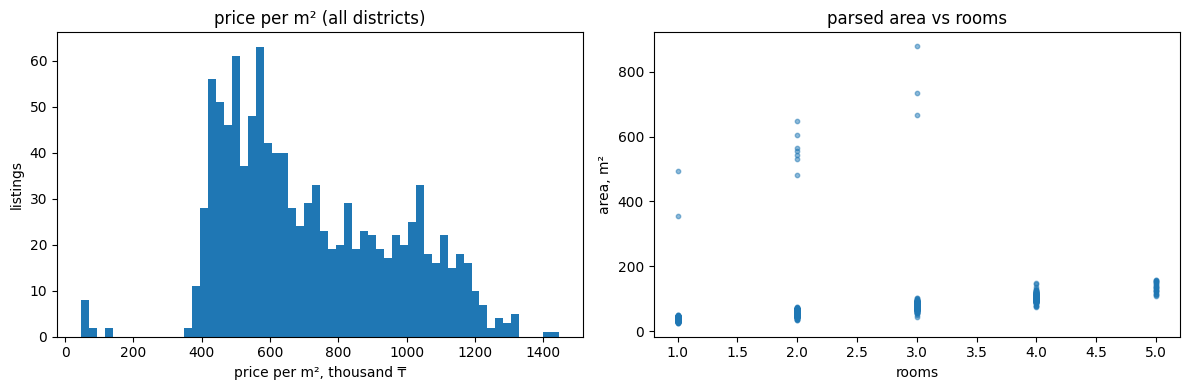

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price_per_m2"] / 1000, bins=60)
axes[0].set_xlabel("price per m², thousand ₸"); axes[0].set_ylabel("listings"); axes[0].set_title("price per m² (all districts)")
axes[1].scatter(df["rooms"], df["area_m2"], s=10, alpha=0.5)
axes[1].set_xlabel("rooms"); axes[1].set_ylabel("area, m²"); axes[1].set_title("parsed area vs rooms")
plt.tight_layout(); plt.show()

The **global** fence flags almost nothing although the histogram has a separate cluster far to the left: district price levels differ
roughly 2× (Alatau/Nauryzbay ≈ 470 k ₸/m² vs Medeu/Bostandyk ≈ 1 M ₸/m²), so the global IQR is very wide and the global lower fence
falls below zero — a value that is absurd *for its district* still sits inside it. Grouping **by `district`** compares each flat with
its own market, so the fences become tight enough to catch the bad rows.

In [17]:
flagged = df.loc[flag_district, ["listing_id", "district", "rooms", "area_m2", "price_kzt", "price_per_m2", "building_type"]].copy()
flagged["district_median_ppm"] = flagged["district"].map(df.groupby("district")["price_per_m2"].median()).round(0)
print(flagged.sort_values("area_m2").to_string())

     listing_id   district  rooms  area_m2  price_kzt   price_per_m2 building_type  district_median_ppm
310   ALM-10605  Nauryzbay      2     54.3   36960000  680662.983425      monolith             476947.0
536   ALM-10405    Turksib      1    356.0   18830000   52893.258427         brick             511374.0
173   ALM-10069    Zhetysu      2    481.0   27710000   57609.147609         brick             621185.0
45    ALM-10264  Bostandyk      1    495.0   42680000   86222.222222         panel             966004.0
293   ALM-10072      Medeu      2    530.0   64270000  121264.150943      monolith            1064710.0
564   ALM-10659    Turksib      2    544.0   25030000   46011.029412         brick             511374.0
908   ALM-10058  Bostandyk      2    555.0   66270000  119405.405405      monolith             966004.0
853   ALM-10909     Alatau      2    565.0   32610000   57716.814159      monolith             466100.0
929   ALM-10276    Turksib      2    604.0   33630000   55678.80

In [18]:
decimal_lost = flag_district & (df["area_m2"] > 250)
typical_per_room = df.loc[~decimal_lost].groupby("rooms")["area_m2"].median()
check = df.loc[decimal_lost, ["listing_id", "rooms", "area_m2", "district", "price_kzt"]].copy()
check["area / 10"] = check["area_m2"] / 10
check["median area for the room count"] = check["rooms"].map(typical_per_room)
check["ppm after fix"] = (check["price_kzt"] / check["area / 10"]).round(0)
check["district median ppm"] = check["district"].map(df.loc[~decimal_lost].groupby("district")["price_per_m2"].median()).round(0)
print(check.to_string())

df.loc[decimal_lost, "area_m2"] = df.loc[decimal_lost, "area_m2"] / 10
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
log("4", "area_m2 with lost decimal point (> 250 m², ppm outlier) divided by 10", len(df), len(df), decimal_lost.sum())

low_g, high_g = fences(df["price_per_m2"], df["district"])
flag_after = (df["price_per_m2"] < low_g) | (df["price_per_m2"] > high_g)
print("\nflagged after the fix:", flag_after.sum())
print(df.loc[flag_after, ["listing_id", "district", "rooms", "area_m2", "year_built", "building_type", "price_kzt", "price_per_m2"]])

     listing_id  rooms  area_m2   district  price_kzt  area / 10  median area for the room count  ppm after fix  district median ppm
45    ALM-10264      1    495.0  Bostandyk   42680000       49.5                           38.00       862222.0             972512.0
173   ALM-10069      2    481.0    Zhetysu   27710000       48.1                           55.90       576091.0             623161.0
293   ALM-10072      2    530.0      Medeu   64270000       53.0                           55.90      1212642.0            1065021.0
536   ALM-10405      1    356.0    Turksib   18830000       35.6                           38.00       528933.0             512155.0
564   ALM-10659      2    544.0    Turksib   25030000       54.4                           55.90       460110.0             512155.0
660   ALM-10440      3    879.0     Auezov   48370000       87.9                           78.55       550284.0             647667.0
709   ALM-10921      3    668.0    Zhetysu   38560000       66.8     

[4] area_m2 with lost decimal point (> 250 m², ppm outlier) divided by 10: 1080 -> 1080 rows, 12 cells changed

flagged after the fix: 1
    listing_id   district  rooms  area_m2  year_built building_type  price_kzt   price_per_m2
310  ALM-10605  Nauryzbay      2     54.3      2006.0      monolith   36960000  680662.983425


In [19]:
still = df.loc[flag_after]
for _, row in still.iterrows():
    peers = df[(df["district"] == row["district"]) & (df["building_type"] == row["building_type"]) & (df.index != row.name)]
    print(f"{row['listing_id']}: {row['price_per_m2']:,.0f} ₸/m²; {row['district']} {row['building_type']} peers: "
          f"median {peers['price_per_m2'].median():,.0f}, 95th pct {peers['price_per_m2'].quantile(0.95):,.0f}, max {peers['price_per_m2'].max():,.0f}")

ALM-10605: 680,663 ₸/m²; Nauryzbay monolith peers: median 531,670, 95th pct 600,164, max 617,430


**Decisions per kind of flagged row**

1. **Area with a lost decimal point (the ~500–900 m² rows) → correct, divide by 10.** A 1–3-room flat cannot be 500–900 m²
   (all other flats with those room counts are 25–160 m²), and their price per m² is 5–15× below the district level. After dividing by 10 the area
   matches the typical size for the room count and the price per m² lands inside the district's normal range (table above) — the row
   becomes consistent with its neighbours, so the fix is better than dropping (price, district and all other columns are fine).
2. **High-but-plausible price per m² (1 row after the fix, ALM-10605, Nauryzbay monolith) → keep.** 681 k ₸/m² is above the
   upper fence and ~10 % above its most expensive Nauryzbay-monolith peer, but only 1.4× the district median, far below the
   city-wide range (Medeu ≈ 1.07 M), and nothing in the row is inconsistent (54 m² fits 2 rooms, floor ≤ total floors, 2006 monolith).
   A premium flat is a real market fact; dropping or changing a real price just because it sits outside a fence would bias the target.

`area_before_fix` keeps the parsed-but-uncorrected area for Step 6a.

In [20]:
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print("saved data/almaty_apartments_clean.csv", df.shape)
print(df.isna().sum())

saved data/almaty_apartments_clean.csv (1080, 13)
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                19
total_floors          0
year_built           71
building_type         0
ceiling_height_m    146
price_kzt             0
price_per_m2          0
area_before_fix       0
dtype: int64


## Step 5 · Missing data
### 5a · Split first
Everything learned from the data from now on (medians, means, std, min/max) is fit on **train only**.

In [21]:
from sklearn.model_selection import train_test_split

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]

train, test = train_test_split(df, test_size=0.2, random_state=YOUR_ID)
train, test = train.copy(), test.copy()
print(train.shape, test.shape)
missing_table = pd.DataFrame({"train NaN": train[NUMERIC].isna().sum(), "train %": (train[NUMERIC].isna().mean() * 100).round(1),
                              "test NaN": test[NUMERIC].isna().sum()})
print(missing_table)

(864, 13) (216, 13)
                  train NaN  train %  test NaN
rooms                     0      0.0         0
area_m2                   0      0.0         0
floor                    14      1.6         5
total_floors              0      0.0         0
year_built               60      6.9        11
ceiling_height_m        118     13.7        28


### 5b · Diagnose the mechanism (train only)

In [22]:
top2 = train[NUMERIC].isna().sum().sort_values(ascending=False).index[:2].tolist()
print("two columns with most missing values:", top2)
rates = pd.DataFrame({col: train.assign(missing=train[col].isna()).groupby("building_type")["missing"].mean()
                      for col in top2 + ["floor"]}).round(3)
rates.loc["overall"] = train[top2 + ["floor"]].isna().mean().round(3)
print(rates)
rows_dropped = len(train) - len(train.dropna(subset=NUMERIC))
for col in top2:
    r = rates.loc[["brick", "monolith", "panel"], col]
    print(f"{col}: missing rate {r.min():.1%} ({r.idxmin()}) .. {r.max():.1%} ({r.idxmax()}), ratio {r.max() / r.min():.1f}x")
print(f"\ndropna() would remove {rows_dropped} of {len(train)} training rows ({rows_dropped / len(train):.1%})")

two columns with most missing values: ['ceiling_height_m', 'year_built']
               ceiling_height_m  year_built  floor
building_type                                     
brick                     0.141       0.088  0.013
monolith                  0.029       0.065  0.014
panel                     0.217       0.061  0.019
overall                   0.137       0.069  0.016
ceiling_height_m: missing rate 2.9% (monolith) .. 21.7% (panel), ratio 7.5x
year_built: missing rate 6.1% (panel) .. 8.8% (brick), ratio 1.4x

dropna() would remove 184 of 864 training rows (21.3%)


In [23]:
for col in top2:
    print(col, "by building_type (median of the known values):",
          train.groupby("building_type")[col].median().to_dict())

ceiling_height_m by building_type (median of the known values): {'brick': 2.92, 'monolith': 2.85, 'panel': 2.59}
year_built by building_type (median of the known values): {'brick': 1979.0, 'monolith': 2015.0, 'panel': 1977.0}


**Verdicts** (numbers from the table above, seed 1234):

* **`ceiling_height_m` → MAR.** Missing in 21.7 % of panel, 14.1 % of brick but only 2.9 % of monolith flats (≈ 7× range).
  Whether it is missing clearly depends on an observed column, and the value itself also depends on building type
  (median 2.59 m panel vs 2.85–2.92 m brick/monolith), so dropping or one global fill would bias it.
* **`year_built` → close to MCAR.** Missing in 8.8 % brick, 6.5 % monolith, 6.1 % panel — a small spread on ~60 missing values, compatible with chance.
  Dropping would not bias it much, but the *value* is strongly tied to building type (median 1977 panel, 1979 brick, 2015 monolith),
  so a per-type fill is still more accurate (5c).
* `floor` (1.3–1.9 % everywhere) → MCAR.

`dropna()` on the numeric columns would remove **184 of 864 training rows (21.3 %)** — too much data to throw away.

### 5c · Masking experiment

In [24]:
from sklearn.metrics import mean_absolute_error

mae = {}
for col in ["ceiling_height_m", "year_built"]:
    known = train[train[col].notna()]
    hidden = known.sample(frac=0.15, random_state=YOUR_ID).index
    rest = train.drop(index=hidden)                    # all an imputer may see
    answers = train.loc[hidden, col]                   # values to recover

    global_pred = pd.Series(rest[col].median(), index=hidden)
    group_med = rest.groupby("building_type")[col].median()
    group_pred = train.loc[hidden, "building_type"].map(group_med)

    mae[col] = {"hidden": len(hidden),
                "global median MAE": mean_absolute_error(answers, global_pred),
                "median by building_type MAE": mean_absolute_error(answers, group_pred)}
print(pd.DataFrame(mae).T.round(4))

                  hidden  global median MAE  median by building_type MAE
ceiling_height_m   112.0             0.1456                       0.0740
year_built         121.0            16.8843                       8.4959


**Result:** ceiling height MAE 0.146 m (global median) vs **0.074 m** (median by building type); year built MAE 16.9 years vs **8.5 years**.
The per-`building_type` median wins for both columns and halves the error — knowing the building type tells you a lot about the missing value.

### 5d · Fill (fit on train, apply to train and test)

| Column | Strategy | Reason |
|---|---|---|
| `ceiling_height_m` | median by `building_type` | MAR on building type; won the masking experiment (0.074 vs 0.146 m MAE) |
| `year_built` | median by `building_type` | near-MCAR, but the value depends on type; won the masking experiment (8.5 vs 16.9 yr MAE) |
| `floor` | global median of train, capped at `total_floors` | few, MCAR-like NaNs; the cap keeps `floor ≤ total_floors` valid |

In [25]:
fill_values = {}
for col in ["ceiling_height_m", "year_built"]:
    med = train.groupby("building_type")[col].median()          # learned on TRAIN only
    fill_values[col] = med.to_dict()
    for frame in (train, test):
        frame[col] = frame[col].fillna(frame["building_type"].map(med))

floor_median = train["floor"].median()                          # learned on TRAIN only
fill_values["floor"] = floor_median
for frame in (train, test):
    frame["floor"] = frame["floor"].fillna(np.minimum(floor_median, frame["total_floors"]))

print("fill values (from train):", fill_values)
n_filled = int(df[NUMERIC].isna().sum().sum())
log("5", "impute year_built, ceiling_height_m (by building_type), floor (median) — fit on train", len(df), len(df), n_filled)

print("NaN left in train:", int(train[NUMERIC].isna().sum().sum()), "| NaN left in test:", int(test[NUMERIC].isna().sum().sum()))
assert train[NUMERIC].isna().sum().sum() == 0 and test[NUMERIC].isna().sum().sum() == 0

fill values (from train): {'ceiling_height_m': {'brick': 2.92, 'monolith': 2.85, 'panel': 2.59}, 'year_built': {'brick': 1979.0, 'monolith': 2015.0, 'panel': 1977.0}, 'floor': np.float64(5.0)}
[5] impute year_built, ceiling_height_m (by building_type), floor (median) — fit on train: 1080 -> 1080 rows, 236 cells changed
NaN left in train: 0 | NaN left in test: 0
